# Model Alignment on the Categorization Task (Levering 2020)

This notebook measures how well LLMs and VLMs align with human decisions in a category learning experiment from [marcelbinz/Psych-101](https://huggingface.co/datasets/marcelbinz/Psych-101).

**Two conditions from Levering (2020):**
- **NLS** (`exp1.csv`, 126 participants): Non-linearly separable rule — no single feature dimension predicts category W vs N
- **LS** (`exp2.csv`, 102 participants): Linearly separable rule — shape alone determines category

**Three analyses:**
1. **Condition comparison** — mean NLL per model on NLS vs LS, averaged across N participants with SE error bars
2. **Contamination check** — standard vs relabeled prompts (W→P, N→Q + code permutation); large NLL increase flags potential memorization
3. **VLM input variants** — text-only vs image-only vs image+text stimulus presentation

### Imports & API Client

In [10]:
import io
import base64
import os
import re

from openai import OpenAI
from dotenv import load_dotenv
from datasets import load_dataset
from tqdm import tqdm

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import matplotlib.gridspec as gridspec

In [11]:
load_dotenv()

client = OpenAI(
    api_key=os.getenv("OPENAI_API_KEY"),
    base_url="https://litellm.ccv.brown.edu"
)

In [19]:
models = client.models.list()

for m in models.data:
    print(m.id)

gemini-3-flash-preview
claude-sonnet-4-5
gpt-5.4
gpt-oss
Llama-3.3-70B-Instruct
Mistral-Large-3
gpt-5.2
gpt-5.2-codex
gemini-2.5-pro
gemini-3.1-flash-lite-preview


### Configuration

In [27]:
# ── Quick-test flag ───────────────────────────────────────────────────────────
# When True: 2 participants, first model only.
# Set False for a fuller run.
# NOTE: N_TRIALS_CAP is always None — the test block (typicality ratings)
# appears at the END of the transcript and must not be cut off.
QUICK_TEST = True

# ── Conditions ────────────────────────────────────────────────────────────────
CONDITION_MAP = {
    "levering2020revisiting/exp1.csv": "NLS",
    "levering2020revisiting/exp2.csv": "LS",
}

# ── Participant sampling ──────────────────────────────────────────────────────
N_PARTICIPANTS   = 1 if QUICK_TEST else 5
PARTICIPANT_SEED = 42
N_TRIALS_CAP     = None  # Always run full transcript — test block is at the end

# ── Token configuration ───────────────────────────────────────────────────────
# NOTE: The Levering dataset assigns different category labels per participant.
# Category tokens are inferred dynamically per participant from their transcript.
# Both categories are mapped onto the shared pseudoword space P / Q (alphabetically).
RELABEL_TARGET_TOKENS = {"P", "Q"}
RATING_TOKENS         = {str(i) for i in range(1, 10)}

# All 8 stimulus codes (3-digit binary strings over {1,2})
ALL_STIMULUS_CODES = ["111", "112", "121", "122", "211", "212", "221", "222"]

# ── Model lists ───────────────────────────────────────────────────────────────
_ALL_LLM_MODELS = [
    "Llama-3.3-70B-Instruct",
]
_ALL_VLM_MODELS = [  #"gemini-2.5-pro",
    "claude-sonnet-4-5",
    "gpt-5.4"
]

LLM_MODELS = _ALL_LLM_MODELS[:1] if QUICK_TEST else _ALL_LLM_MODELS
VLM_MODELS = _ALL_VLM_MODELS[:1] if QUICK_TEST else _ALL_VLM_MODELS

print(f"QUICK_TEST={QUICK_TEST} | participants={N_PARTICIPANTS} | trials_cap={N_TRIALS_CAP}")
print(f"LLM models: {LLM_MODELS}")
print(f"VLM models: {VLM_MODELS}")


QUICK_TEST=True | participants=1 | trials_cap=None
LLM models: ['Llama-3.3-70B-Instruct']
VLM models: ['claude-sonnet-4-5']


### Load Dataset — Both Conditions

In [28]:
dataset = load_dataset("marcelbinz/Psych-101")
df = pd.DataFrame(dataset["train"])

condition_dfs = {}
for exp_name, condition in CONDITION_MAP.items():
    condition_dfs[exp_name] = df[df["experiment"] == exp_name].reset_index(drop=True)
    print(f"{condition} ({exp_name}): {len(condition_dfs[exp_name])} participants")

print("Using fixed condition-token mapping for Levering transcripts.")


NLS (levering2020revisiting/exp1.csv): 126 participants
LS (levering2020revisiting/exp2.csv): 102 participants
Using fixed condition-token mapping for Levering transcripts.


In [29]:
# Preview participant sampling (deterministic via seed)
rng_preview = np.random.default_rng(PARTICIPANT_SEED)
for exp_name, condition in CONDITION_MAP.items():
    n = len(condition_dfs[exp_name])
    idxs = rng_preview.choice(n, size=N_PARTICIPANTS, replace=False).tolist()
    print(f"{condition}: sampled participant indices = {idxs}")

NLS: sampled participant indices = [11]
LS: sampled participant indices = [78]


### Helper Functions

- `extract_steps` — unchanged from original; parses `<<DECISION>>` markers
- `compute_nll` — unchanged; computes NLL of a human decision from logprobs
- `relabel_text` — applies contamination-check relabeling: W→P, N→Q + code permutation
- `render_stimulus` — copied from `simulation.ipynb`; renders a 3-digit code as a base64 PNG

In [30]:
# ── extract_steps ─────────────────────────────────────────────────────────────
def extract_steps(text):
    pattern = r"<<(.*?)>>"
    matches = list(re.finditer(pattern, text))
    steps = []
    prev_end = 0
    for m in matches:
        start, end = m.span()
        decision = m.group(1).strip()
        prefix = text[prev_end:start]
        if decision.lower() == "nan":
            prev_end = end
            continue
        steps.append({"prefix": prefix, "decision": decision})
        prev_end = end
    return steps


# ── compute_nll ───────────────────────────────────────────────────────────────
def compute_nll(logprobs, human_decision, valid_tokens):
    """Forced-choice NLL: renormalize over the two valid category tokens only.

    Returns NaN when either valid token is absent from top_logprobs.
    """
    if logprobs is None:
        return np.nan

    if human_decision not in valid_tokens:
        return np.nan

    valid_entries = {}
    for entry in logprobs:
        tok = entry.token.strip().upper()
        if tok in valid_tokens and tok not in valid_entries:
            valid_entries[tok] = entry.logprob

    # Require both tokens to be present for a meaningful forced-choice NLL
    if len(valid_entries) < len(valid_tokens):
        return np.nan

    log_probs = np.array(list(valid_entries.values()), dtype=float)
    probs = np.exp(log_probs - np.max(log_probs))
    probs /= probs.sum()
    human_idx = list(valid_entries.keys()).index(human_decision)
    return float(-np.log(probs[human_idx]))


def compute_human_raw_logprob(logprobs, human_decision, valid_tokens):
    """Return the raw (unnormalized) logprob assigned to the human's token.

    Unlike compute_nll, this preserves absolute calibration — if the model
    assigns logprob=-0.001 to the correct token that is very different from
    logprob=-2.0, even if both renormalize to NLL~0.
    Returns NaN when the human's token is absent from top_logprobs.
    """
    if logprobs is None or human_decision not in valid_tokens:
        return np.nan
    for entry in logprobs:
        if entry.token.strip().upper() == human_decision:
            return float(entry.logprob)
    return np.nan  # token not in top-k


def compute_p_category(logprobs, human_decision, valid_tokens):
    """Forced-choice P(human_decision): probability mass on human's category token.

    Used to correlate model confidence with human typicality ratings on test trials.
    Returns NaN when either token is missing from top_logprobs.
    """
    nll = compute_nll(logprobs, human_decision, valid_tokens)
    if np.isnan(nll):
        return np.nan
    return float(np.exp(-nll))


def label_phases(steps):
    """Tag each step as 'train', 'test_category', or 'test_rating'.

    Test trials are identified by a category decision immediately followed by a
    1–9 typicality rating in the same transcript block.
    """
    labeled = []
    for i, step in enumerate(steps):
        d = step["decision"]
        if d in RATING_TOKENS:
            labeled.append({**step, "phase": "test_rating"})
        else:
            next_step = steps[i + 1] if i + 1 < len(steps) else None
            is_test = next_step is not None and next_step["decision"] in RATING_TOKENS
            labeled.append({**step, "phase": "test_category" if is_test else "train"})
    return labeled


# ── infer_category_tokens ────────────────────────────────────────────────────
def infer_category_tokens(steps):
    """Infer the two category labels used by this participant from their transcript.

    Returns a sorted tuple (token_A, token_B) where token_A < token_B alphabetically.
    Also returns the relabel map {token_A: "P", token_B: "Q"}.
    """
    tokens = sorted({
        step["decision"] for step in steps
        if step["decision"] not in RATING_TOKENS
    })
    assert len(tokens) == 2, f"Expected exactly 2 category tokens, found: {tokens}"
    relabel_map = {tokens[0]: "P", tokens[1]: "Q"}
    return set(tokens), relabel_map


# ── relabel_text ──────────────────────────────────────────────────────────────
def relabel_text(text, relabel_map):
    """Contamination-check relabeling.

    1. Permute 3-digit stimulus codes: swap positions 0 and 2 (XYZ -> ZYX).
       e.g. '122' -> '221', '211' -> '112'. All 8 codes permute within the set.
    2. Replace participant-specific category labels with pseudowords P/Q.
    """
    def _permute(m):
        c = m.group(0)
        return c[2] + c[1] + c[0]

    text = re.sub(r'\b[12]{3}\b', _permute, text)

    for old, new in relabel_map.items():
        text = re.sub(rf'\b{re.escape(old)}\b', new, text)

    return text


def summarize_decision_space(steps):
    return sorted({
        step["decision"] for step in steps
        if step["decision"] not in RATING_TOKENS
    })


# ── render_stimulus ───────────────────────────────────────────────────────────
def render_stimulus(code, dpi=80):
    """Render a 3-digit stimulus code as a base64-encoded PNG image.
    digit 1 — shape  (1=square, 2=triangle)
    digit 2 — size   (1=large, 2=small)
    digit 3 — shade  (1=black, 2=white)
    Copied from simulation.ipynb.
    """
    shape = int(code[0])
    size  = int(code[1])
    shade = int(code[2])

    fig, ax = plt.subplots(figsize=(2, 2))
    ax.set_xlim(0, 1); ax.set_ylim(0, 1)
    ax.set_aspect("equal"); ax.axis("off")
    fig.patch.set_facecolor("#c8c8c8")

    sz = 0.55 if size == 1 else 0.32
    fc = "black" if shade == 1 else "white"
    cx, cy = 0.5, 0.5

    if shape == 1:
        patch = patches.Rectangle(
            (cx - sz/2, cy - sz/2), sz, sz,
            facecolor=fc, edgecolor="black", linewidth=2
        )
    else:
        h   = sz * np.sqrt(3) / 2
        pts = np.array([[cx, cy + 2*h/3],
                        [cx - sz/2, cy - h/3],
                        [cx + sz/2, cy - h/3]])
        patch = patches.Polygon(pts, closed=True,
                                facecolor=fc, edgecolor="black", linewidth=2)
    ax.add_patch(patch)

    buf = io.BytesIO()
    fig.savefig(buf, format="png", dpi=dpi, bbox_inches="tight", pad_inches=0.05)
    plt.close(fig)
    buf.seek(0)
    return base64.b64encode(buf.read()).decode("utf-8")


In [31]:
# Pre-render all 8 stimulus images once (used by VLM image variants)
STIMULUS_IMAGES = {code: render_stimulus(code) for code in ALL_STIMULUS_CODES}
print(f"Pre-rendered {len(STIMULUS_IMAGES)} stimulus images.")

Pre-rendered 8 stimulus images.


### Alignment Loop

`run_alignment` runs one model on one participant's steps and returns per-trial `(human_decisions, logprobs, correct)`.

**`input_variant`** (VLMs only):
- `"text_only"` — plain text prompt, same as LLM path
- `"image_only"` — current trial's stimulus replaced with a PNG; prior history stays as text
- `"image_and_text"` — same as image_only but code string also included as caption alongside image

In [32]:
def run_alignment(model, steps, valid_tokens, input_variant="text_only", top_logprobs_k=20):
    """Run alignment for one model on one participant's step sequence.

    Args:
        model:         LiteLLM model string
        steps:         output of extract_steps() — may be standard or relabeled
        valid_tokens:  set of valid category token strings
        input_variant: "text_only" | "image_only" | "image_and_text"
        top_logprobs_k: number of top logprobs to request

    Returns:
        human_decisions: list[str]  — category decisions only (ratings excluded)
        logprobs_list:   list       — top_logprobs per trial, or None if unsupported
        correct_list:    list[bool] — whether model's top token matched human
    """
    model_context    = ""
    human_decisions  = []
    logprobs_list    = []
    correct_list     = []
    cue = f"\nRespond with only one token: {' or '.join(sorted(valid_tokens))}."

    for step in steps:
        human_decision = step["decision"]
        prefix         = step["prefix"]

        # Rating steps: update context silently, skip API call
        if human_decision in RATING_TOKENS:
            model_context += prefix + f"<<{human_decision}>>"
            continue

        full_text = model_context + prefix

        # ── Build message ──────────────────────────────────────────────────
        if input_variant == "text_only":
            messages = [{"role": "user", "content": full_text + cue}]
        else:
            img_matches = list(re.finditer(r'image (\d{3})', full_text))
            if img_matches:
                m = img_matches[-1]
                code = m.group(1)
                img_b64 = STIMULUS_IMAGES.get(code, STIMULUS_IMAGES[ALL_STIMULUS_CODES[0]])
                before = full_text[:m.start()] + "image "
                after  = full_text[m.end():]

                if input_variant == "image_only":
                    content = [
                        {"type": "text",      "text": before},
                        {"type": "image_url", "image_url": {"url": f"data:image/png;base64,{img_b64}"}},
                        {"type": "text",      "text": after + cue},
                    ]
                else:  # image_and_text
                    content = [
                        {"type": "text",      "text": before},
                        {"type": "image_url", "image_url": {"url": f"data:image/png;base64,{img_b64}"}},
                        {"type": "text",      "text": f" (code: {code})" + after + cue},
                    ]
                messages = [{"role": "user", "content": content}]
            else:
                messages = [{"role": "user", "content": full_text + cue}]

        # Update context with the *human* decision regardless of model output
        model_context += prefix + f"<<{human_decision}>>"

        lp = None
        top_token = None

        try:
            resp = client.chat.completions.create(
                model=model,
                messages=messages,
                logprobs=True,
                top_logprobs=top_logprobs_k,
            )

            choice = resp.choices[0]
            if getattr(choice, "logprobs", None) and getattr(choice.logprobs, "content", None):
                content_logprobs = choice.logprobs.content
                if content_logprobs and getattr(content_logprobs[0], "top_logprobs", None):
                    lp = content_logprobs[0].top_logprobs

            if lp:
                tokens_in_space = [entry.token.strip().upper() for entry in lp if entry.token.strip().upper() in valid_tokens]
                if tokens_in_space:
                    best_entry = min(
                        (entry for entry in lp if entry.token.strip().upper() in valid_tokens),
                        key=lambda entry: -entry.logprob
                    )
                    top_token = best_entry.token.strip().upper()

            if top_token is None and getattr(choice, "message", None) and getattr(choice.message, "content", None):
                raw = str(choice.message.content).strip().upper()
                top_token = next((t for t in sorted(valid_tokens) if t in raw), None)

        except Exception as e:
            err = str(e).lower()
            if any(x in err for x in ["logprob", "400", "unsupported", "not supported"]):
                # Fallback: accuracy only, no NLL
                try:
                    resp = client.chat.completions.create(model=model, messages=messages)
                    raw = resp.choices[0].message.content.strip().upper()
                    top_token = next((t for t in sorted(valid_tokens) if t in raw), None)
                except Exception as e2:
                    print(f"    [fallback error] {model}: {e2}")
            else:
                print(f"    [error] {model}: {e}")

        human_decisions.append(human_decision)
        logprobs_list.append(lp)
        correct_list.append(top_token == human_decision if top_token else None)

    return human_decisions, logprobs_list, correct_list


In [33]:
# ── Main loop ─────────────────────────────────────────────────────────────────
# raw_results key: (model, condition, prompt_variant, input_variant)
# raw_results value:
#   "nll_train"      : [[per-trial NLL, training phase]    × N_PARTICIPANTS]
#   "nll_test"       : [[per-trial NLL, test phase]        × N_PARTICIPANTS]
#   "raw_lp_train"   : [[raw logprob of human token, train] × N_PARTICIPANTS]
#   "correct"        : [[bool]                              × N_PARTICIPANTS]
#   "typicality"     : [[(p_category, rating)]              × N_PARTICIPANTS]  (standard only)

raw_results = {}
rng = np.random.default_rng(PARTICIPANT_SEED)

for exp_name, condition in CONDITION_MAP.items():
    exp_df = condition_dfs[exp_name]
    pidxs = rng.choice(len(exp_df), size=N_PARTICIPANTS, replace=False).tolist()

    print(f"\n{'='*60}")
    print(f"Condition: {condition}  |  participants: {pidxs}")
    print(f"{'='*60}")

    for pidx in pidxs:
        full_text = exp_df["text"].iloc[pidx]
        steps_std = extract_steps(full_text)

        if N_TRIALS_CAP is not None:
            steps_std = steps_std[:N_TRIALS_CAP]

        # Infer this participant's category tokens dynamically
        standard_tokens, relabel_map = infer_category_tokens(steps_std)
        steps_rel = extract_steps(relabel_text(full_text, relabel_map))

        if N_TRIALS_CAP is not None:
            steps_rel = steps_rel[:N_TRIALS_CAP]

        # Label phases (train / test_category / test_rating) for standard steps
        labeled_std = label_phases(steps_std)
        labeled_rel = label_phases(steps_rel)

        print(f"  participant {pidx}: standard_tokens={sorted(standard_tokens)} | relabel_map={relabel_map}")
        n_train = sum(1 for s in labeled_std if s["phase"] == "train")
        n_test  = sum(1 for s in labeled_std if s["phase"] == "test_category")
        print(f"  train trials={n_train} | test trials={n_test}")

        # ── LLMs: standard + relabeled, text_only ─────────────────────────
        for model in LLM_MODELS:
            for pv, cur_steps, labeled, vtokens in [
                ("standard",  steps_std, labeled_std, standard_tokens),
                ("relabeled", steps_rel, labeled_rel, RELABEL_TARGET_TOKENS),
            ]:
                key = (model, condition, pv, "text_only")
                print(f"  {model} | {condition} | {pv} | text_only  (participant {pidx})")
                hd, lp, correct = run_alignment(model, cur_steps, vtokens, "text_only")

                # Phase mask: align phases with category-only decisions returned by run_alignment
                cat_phases = [s["phase"] for s in labeled if s["decision"] not in RATING_TOKENS]

                nll_train, nll_test = [], []
                for h, l, phase in zip(hd, lp, cat_phases):
                    nll_val = compute_nll(l, h, vtokens)
                    if phase == "train":
                        nll_train.append(nll_val)
                    else:
                        nll_test.append(nll_val)

                # Typicality pairs: (model P(category), human rating) for test trials (standard only)
                typ_pairs = []
                if pv == "standard":
                    test_lp = [l for l, phase in zip(lp, cat_phases) if phase == "test_category"]
                    test_hd = [h for h, phase in zip(hd, cat_phases) if phase == "test_category"]
                    # Collect matching typicality ratings from labeled steps
                    ratings = [
                        int(labeled[i+1]["decision"])
                        for i, s in enumerate(labeled)
                        if s["phase"] == "test_category" and i+1 < len(labeled)
                        and labeled[i+1]["phase"] == "test_rating"
                    ]
                    for h, l, r in zip(test_hd, test_lp, ratings):
                        p = compute_p_category(l, h, vtokens)
                        if not np.isnan(p):
                            typ_pairs.append((p, r))

                raw_lp_train = [compute_human_raw_logprob(l, h, vtokens)
                                for h, l, phase in zip(hd, lp, cat_phases) if phase == "train"]
                raw_results.setdefault(key, {"nll_train": [], "nll_test": [], "raw_lp_train": [], "correct": [], "typicality": []})
                raw_results[key]["nll_train"].append(nll_train)
                raw_results[key]["nll_test"].append(nll_test)
                raw_results[key]["raw_lp_train"].append(raw_lp_train)
                raw_results[key]["correct"].append(correct)
                raw_results[key]["typicality"].append(typ_pairs)

        # ── VLMs: standard (3 input variants) + relabeled text_only ───────
        for model in VLM_MODELS:
            for iv in ["text_only", "image_only", "image_and_text"]:
                key = (model, condition, "standard", iv)
                print(f"  {model} | {condition} | standard | {iv}  (participant {pidx})")
                hd, lp, correct = run_alignment(model, steps_std, standard_tokens, iv)
                cat_phases = [s["phase"] for s in labeled_std if s["decision"] not in RATING_TOKENS]
                nll_train = [compute_nll(l, h, standard_tokens) for h, l, ph in zip(hd, lp, cat_phases) if ph == "train"]
                nll_test  = [compute_nll(l, h, standard_tokens) for h, l, ph in zip(hd, lp, cat_phases) if ph == "test_category"]
                raw_lp_train = [compute_human_raw_logprob(l, h, standard_tokens)
                                for h, l, ph in zip(hd, lp, cat_phases) if ph == "train"]
                raw_results.setdefault(key, {"nll_train": [], "nll_test": [], "raw_lp_train": [], "correct": [], "typicality": []})
                raw_results[key]["nll_train"].append(nll_train)
                raw_results[key]["nll_test"].append(nll_test)
                raw_results[key]["raw_lp_train"].append(raw_lp_train)
                raw_results[key]["correct"].append(correct)
                raw_results[key]["typicality"].append([])

            key = (model, condition, "relabeled", "text_only")
            print(f"  {model} | {condition} | relabeled | text_only  (participant {pidx})")
            hd, lp, correct = run_alignment(model, steps_rel, RELABEL_TARGET_TOKENS, "text_only")
            cat_phases = [s["phase"] for s in labeled_rel if s["decision"] not in RATING_TOKENS]
            nll_train = [compute_nll(l, h, RELABEL_TARGET_TOKENS) for h, l, ph in zip(hd, lp, cat_phases) if ph == "train"]
            nll_test  = [compute_nll(l, h, RELABEL_TARGET_TOKENS) for h, l, ph in zip(hd, lp, cat_phases) if ph == "test_category"]
            raw_lp_train = [compute_human_raw_logprob(l, h, RELABEL_TARGET_TOKENS)
                            for h, l, ph in zip(hd, lp, cat_phases) if ph == "train"]
            raw_results.setdefault(key, {"nll_train": [], "nll_test": [], "raw_lp_train": [], "correct": [], "typicality": []})
            raw_results[key]["nll_train"].append(nll_train)
            raw_results[key]["nll_test"].append(nll_test)
            raw_results[key]["raw_lp_train"].append(raw_lp_train)
            raw_results[key]["correct"].append(correct)
            raw_results[key]["typicality"].append([])

print("\nDone. Keys collected:", len(raw_results))



Condition: NLS  |  participants: [11]
  participant 11: standard_tokens=['C', 'X'] | relabel_map={'C': 'P', 'X': 'Q'}
  train trials=150 | test trials=8
  Llama-3.3-70B-Instruct | NLS | standard | text_only  (participant 11)
  Llama-3.3-70B-Instruct | NLS | relabeled | text_only  (participant 11)
  claude-sonnet-4-5 | NLS | standard | text_only  (participant 11)
  claude-sonnet-4-5 | NLS | standard | image_only  (participant 11)
  claude-sonnet-4-5 | NLS | standard | image_and_text  (participant 11)
  claude-sonnet-4-5 | NLS | relabeled | text_only  (participant 11)

Condition: LS  |  participants: [78]
  participant 78: standard_tokens=['G', 'H'] | relabel_map={'G': 'P', 'H': 'Q'}
  train trials=150 | test trials=8
  Llama-3.3-70B-Instruct | LS | standard | text_only  (participant 78)
  Llama-3.3-70B-Instruct | LS | relabeled | text_only  (participant 78)
  claude-sonnet-4-5 | LS | standard | text_only  (participant 78)
    [fallback error] claude-sonnet-4-5: Connection error.
    [e

KeyboardInterrupt: 

### Compute NLL & Top-1 Accuracy

In [10]:
# ── Diagnostics: inspect raw logprob values ───────────────────────────────────
import math

print("=== NLL Distribution Diagnostics ===")

for key, data in raw_results.items():
    model, cond, pv, iv = key
    if iv != "text_only":
        continue

    all_nll = [x for trials in data["nll_train"] + data["nll_test"] for x in trials]
    finite  = [x for x in all_nll if x is not None and math.isfinite(x)]
    nan_ct  = sum(1 for x in all_nll if x is None or not math.isfinite(x))

    if not finite:
        print(f"{model} | {cond} | {pv}: all NaN ({len(all_nll)} trials)")
        continue

    above_chance = sum(1 for x in finite if x > math.log(2))
    print(
        f"{model} | {cond} | {pv}:\n"
        f"  trials total={len(all_nll)}  finite={len(finite)}  NaN={nan_ct}\n"
        f"  NLL  min={min(finite):.3f}  median={sorted(finite)[len(finite)//2]:.3f}  "
        f"max={max(finite):.3f}  mean={sum(finite)/len(finite):.3f}\n"
        f"  above-chance (>{math.log(2):.3f}): {above_chance}/{len(finite)} "
        f"({100*above_chance/len(finite):.0f}%)\n"
    )


=== NLL Distribution Diagnostics ===
Llama-3.3-70B-Instruct | NLS | standard:
  trials total=158  finite=158  NaN=0
  NLL  min=-0.000  median=0.117  max=48.750  mean=10.645
  above-chance (>0.693): 72/158 (46%)

Llama-3.3-70B-Instruct | NLS | relabeled:
  trials total=158  finite=158  NaN=0
  NLL  min=0.000  median=1.113  max=43.177  mean=9.214
  above-chance (>0.693): 80/158 (51%)

Llama-3.3-70B-Instruct | LS | standard:
  trials total=158  finite=135  NaN=23
  NLL  min=-0.000  median=0.000  max=43.750  mean=2.051
  above-chance (>0.693): 14/135 (10%)

Llama-3.3-70B-Instruct | LS | relabeled:
  trials total=158  finite=152  NaN=6
  NLL  min=-0.000  median=0.000  max=41.667  mean=1.693
  above-chance (>0.693): 12/152 (8%)



In [ ]:
# ── Deep diagnostics: token-presence breakdown & mean NLL ───────────────────
# Inserted after existing diagnostics cell.
# Works entirely from stored raw_results (nll_train, raw_lp_train, nll_test).
# Does NOT modify compute_nll or any other existing code.
import math

LOG2 = math.log(2)  # chance NLL threshold (≈0.693) for a 2-AFC task

def _classify_trials(nll_list, raw_lp_list):
    """Return three lists of (nll, raw_lp) pairs for each category.

    Categories:
      both_found   – both valid tokens in top-k; NLL is meaningful
      human_only   – only the human token found in top-k;
                     model so confident in human choice the other fell out
                     → treated as 'high confidence correct'
      human_missing – human token not in top-k;
                     other token found (high-conf wrong) OR neither found
    """
    both_found, human_only, human_missing = [], [], []
    for nll, rlp in zip(nll_list, raw_lp_list):
        nll_ok = (nll is not None and math.isfinite(nll))
        rlp_ok = (rlp is not None and math.isfinite(rlp))
        if nll_ok:
            both_found.append((nll, rlp))
        elif rlp_ok:
            human_only.append((nll, rlp))
        else:
            human_missing.append((nll, rlp))
    return both_found, human_only, human_missing


def _nll_stats(vals):
    """Return dict of mean, median, above-chance count for a list of finite NLL values."""
    if not vals:
        return None
    s = sorted(vals)
    n = len(s)
    above = sum(1 for x in s if x > LOG2)
    return dict(mean=sum(s)/n, median=s[n//2], above=above, n=n)


print("=" * 70)
print("DEEP DIAGNOSTIC 1 — Token-presence breakdown (train trials, text_only)")
print("=" * 70)

for key, data in sorted(raw_results.items()):
    model, cond, pv, iv = key
    if iv != "text_only":
        continue

    nll_flat  = [x for part in data["nll_train"]    for x in part]
    rlp_flat  = [x for part in data["raw_lp_train"] for x in part]
    n_total   = len(nll_flat)
    if n_total == 0:
        continue

    bf, ho, hm = _classify_trials(nll_flat, rlp_flat)

    print(f"\n{model} | {cond} | {pv}  ({n_total} train trials)")
    print(f"  (a) Both tokens in top-k : {len(bf):4d} ({100*len(bf)/n_total:5.1f}%)  — NLL computed normally")
    print(f"  (b) Only human token     : {len(ho):4d} ({100*len(ho)/n_total:5.1f}%)  — high-confidence CORRECT (other token fell below top-k)")
    print(f"  (c) Human token missing  : {len(hm):4d} ({100*len(hm)/n_total:5.1f}%)  — high-conf WRONG or neither token found")

    # (a) NLL statistics for both-found trials
    if bf:
        st = _nll_stats([nll for nll, _ in bf])
        print(f"  [Both-found NLL]  mean={st['mean']:.4f}  median={st['median']:.4f}  "
              f"above-chance={st['above']}/{st['n']} ({100*st['above']/st['n']:.1f}%)")

    # (b) Raw logprob distribution for human-only trials (LS diagnosis)
    if ho:
        rlp_vals = sorted([rlp for _, rlp in ho])
        mean_rlp = sum(rlp_vals) / len(rlp_vals)
        near_certain = sum(1 for r in rlp_vals if r > -0.05)
        print(f"  [Human-only raw lp]  mean={mean_rlp:.4f}  "
              f"min={rlp_vals[0]:.3f}  max={rlp_vals[-1]:.3f}  "
              f"near-certain (lp>-0.05): {near_certain}/{len(rlp_vals)}")

    # Condition-specific: show raw lp distribution for the human token across ALL train trials
    if cond == "LS":
        all_rlp = sorted([rlp for rlp in rlp_flat if rlp is not None and math.isfinite(rlp)])
        if all_rlp:
            n_rlp = len(all_rlp)
            q25 = all_rlp[n_rlp // 4]
            q75 = all_rlp[3 * n_rlp // 4]
            print(f"  [LS human-token raw lp, all train] "
                  f"min={all_rlp[0]:.3f}  p25={q25:.3f}  "
                  f"median={all_rlp[n_rlp//2]:.3f}  p75={q75:.3f}  max={all_rlp[-1]:.3f}")


print()
print("=" * 70)
print("DEEP DIAGNOSTIC 2 — Mean NLL vs Median NLL (train + test, text_only)")
print("  (includes ONLY both-found trials; NaN trials classified above)")
print("=" * 70)
print(f"\n{'Model':30s} | {'Cond':5s} | {'Variant':10s} | {'Phase':5s} | "
      f"{'Mean NLL':>9} | {'Median':>8} | {'Above-chance':>12}")
print("-" * 100)

for key, data in sorted(raw_results.items()):
    model, cond, pv, iv = key
    if iv != "text_only":
        continue
    for phase_label, nll_lists in [("train", data["nll_train"]), ("test", data["nll_test"])]:
        finite = [x for part in nll_lists for x in part if x is not None and math.isfinite(x)]
        if finite:
            st = _nll_stats(finite)
            print(f"{model:30s} | {cond:5s} | {pv:10s} | {phase_label:5s} | "
                  f"{st['mean']:>9.4f} | {st['median']:>8.4f} | "
                  f"{st['above']:>5}/{st['n']:<5} ({100*st['above']/st['n']:>5.1f}%)")
        else:
            print(f"{model:30s} | {cond:5s} | {pv:10s} | {phase_label:5s} | all NaN")


print()
print("=" * 70)
print("DEEP DIAGNOSTIC 3 — NaN trial classification summary")
print("  (b) = high-confidence CORRECT  [only human token in top-k]")
print("  (c) = high-confidence WRONG or neither token  [human token absent]")
print("  NaN trials are currently EXCLUDED from NLL metrics — see above.")
print("  If (b) >> (c), reported NLL OVERESTIMATES error (model was MORE right)")
print("=" * 70)

for key, data in sorted(raw_results.items()):
    model, cond, pv, iv = key
    if iv != "text_only":
        continue
    nll_flat = [x for part in data["nll_train"] for x in part]
    rlp_flat = [x for part in data["raw_lp_train"] for x in part]
    n = len(nll_flat)
    if n == 0:
        continue
    bf, ho, hm = _classify_trials(nll_flat, rlp_flat)
    nan_total = len(ho) + len(hm)
    if nan_total == 0:
        continue  # skip clean cases to reduce noise
    nan_pct = 100 * nan_total / n
    ho_pct = 100 * len(ho) / nan_total if nan_total else 0
    hm_pct = 100 * len(hm) / nan_total if nan_total else 0
    print(f"  {model} | {cond} | {pv}: "
          f"{nan_total}/{n} NaN ({nan_pct:.1f}%)  "
          f"→ (b) high-conf correct: {len(ho)} ({ho_pct:.0f}% of NaN)  "
          f"(c) human missing: {len(hm)} ({hm_pct:.0f}% of NaN)")


In [13]:
# Aggregate per-participant metrics
metrics = {}

for key, data in raw_results.items():
    def summarize(nll_lists):
        p_stats = []
        for trials in nll_lists:
            finite = [x for x in trials if x is not None and np.isfinite(x)]
            p_stats.append({
                "median": float(np.median(finite)) if finite else np.nan,
                "mean":   float(np.mean(finite))   if finite else np.nan,
                "n":      len(finite),
            })
        medians = [p["median"] for p in p_stats if np.isfinite(p["median"])]
        return {
            "median_nll": float(np.median(medians)) if medians else np.nan,
            "mean_nll":   float(np.mean(medians))   if medians else np.nan,
            "se_nll":     float(np.std(medians, ddof=0) / np.sqrt(len(medians))) if len(medians) > 1 else 0.0,
            "participant_medians": medians,
        }

    def nan_rate(nll_lists):
        """Fraction of trials that returned NaN (token missing from top-k)."""
        all_vals = [x for trials in nll_lists for x in trials]
        if not all_vals:
            return np.nan
        return float(sum(1 for x in all_vals if x is None or not np.isfinite(x)) / len(all_vals))

    def mean_raw_logprob(lp_lists):
        """Mean raw logprob of human token across all finite train trials."""
        all_vals = [x for trials in lp_lists for x in trials
                    if x is not None and np.isfinite(x)]
        return float(np.mean(all_vals)) if all_vals else np.nan

    p_acc = []
    for trials in data["correct"]:
        finite = [c for c in trials if c is not None]
        p_acc.append(float(np.mean(finite)) if finite else np.nan)

    # Typicality Spearman correlation per participant
    typ_corrs = []
    for pairs in data["typicality"]:
        if len(pairs) >= 4:
            p_cats = [p for p, r in pairs]
            ratings = [r for p, r in pairs]
            r, pval = stats.spearmanr(p_cats, ratings)
            typ_corrs.append(float(r))

    metrics[key] = {
        **summarize(data["nll_train"]),
        "train": summarize(data["nll_train"]),
        "test":  summarize(data["nll_test"]),
        "nan_rate_train":    nan_rate(data["nll_train"]),
        "mean_raw_lp_train": mean_raw_logprob(data.get("raw_lp_train", [])),
        "mean_acc": float(np.nanmean(p_acc)) if p_acc else np.nan,
        "typ_spearman_mean": float(np.mean(typ_corrs))   if typ_corrs else np.nan,
        "typ_spearman_se":   float(np.std(typ_corrs, ddof=0) / np.sqrt(len(typ_corrs))) if len(typ_corrs) > 1 else 0.0,
        "typ_corrs": typ_corrs,
    }

    model, cond, pv, iv = key
    m = metrics[key]
    print(
        f"{model} | {cond} | {pv} | {iv}:\n"
        f"  train median NLL={m['train']['median_nll']:.3f}  acc={m['mean_acc']:.1%}"
        f"  NaN rate={m['nan_rate_train']:.1%}  mean raw logprob={m['mean_raw_lp_train']:.3f}\n"
        f"  typicality Spearman r={m['typ_spearman_mean']:.3f} (n={len(m['typ_corrs'])} participants)"
    )


Llama-3.3-70B-Instruct | NLS | standard | text_only:
  train median NLL=0.155  acc=54.4%  NaN rate=0.0%  mean raw logprob=-11.085
  typicality Spearman r=-0.577 (n=1 participants)
Llama-3.3-70B-Instruct | NLS | relabeled | text_only:
  train median NLL=3.112  acc=48.7%  NaN rate=0.0%  mean raw logprob=-9.455
  typicality Spearman r=nan (n=0 participants)
Llama-3.3-70B-Instruct | LS | standard | text_only:
  train median NLL=0.000  acc=91.1%  NaN rate=15.3%  mean raw logprob=-1.537
  typicality Spearman r=0.056 (n=1 participants)
Llama-3.3-70B-Instruct | LS | relabeled | text_only:
  train median NLL=0.000  acc=92.4%  NaN rate=4.0%  mean raw logprob=-1.438
  typicality Spearman r=nan (n=0 participants)


### Visualize Results

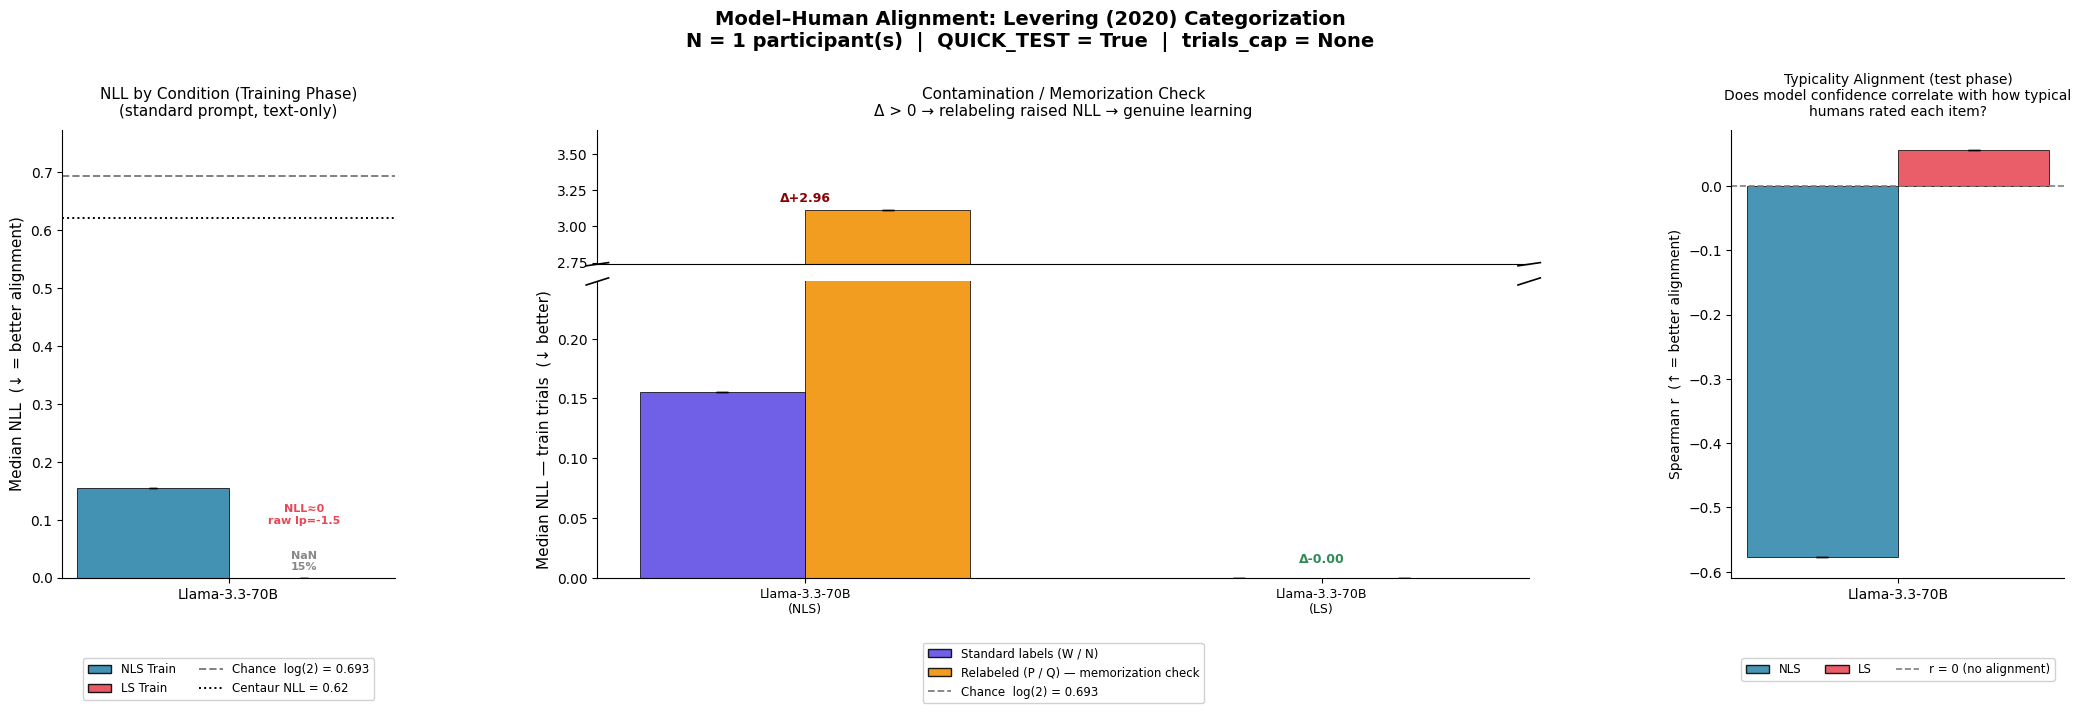

In [15]:
import math
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
import matplotlib.ticker as ticker
import numpy as np

# ── Constants ──────────────────────────────────────────────────────────────────
LOG2        = math.log(2)
CENTAUR_NLL = 0.62

COND_COLORS    = {"NLS": "#2E86AB", "LS": "#E84855"}
VARIANT_COLORS = {"standard": "#5C4AE4", "relabeled": "#F18F01"}
CONDITIONS     = ["NLS", "LS"]

def short_name(m):
    return m.replace("-Instruct", "").replace("-instruct", "")

# ── Model lists ────────────────────────────────────────────────────────────────
p1_models = [
    m for m in dict.fromkeys(k[0] for k in metrics if k[2] == "standard" and k[3] == "text_only")
    if any(np.isfinite(metrics.get((m, c, "standard", "text_only"), {}).get("train", {}).get("median_nll", np.nan))
           for c in CONDITIONS)
]

pairs = [(m, c) for m in p1_models for c in CONDITIONS
         if np.isfinite(metrics.get((m, c, "standard",  "text_only"), {}).get("train", {}).get("median_nll", np.nan))
         or np.isfinite(metrics.get((m, c, "relabeled", "text_only"), {}).get("train", {}).get("median_nll", np.nan))]

# ── Figure layout ──────────────────────────────────────────────────────────────
fig = plt.figure(figsize=(22, 8))
gs  = gridspec.GridSpec(
    1, 3,
    width_ratios=[max(len(p1_models), 1), max(len(pairs), 1) * 1.4, max(len(p1_models), 1)],
    wspace=0.38,          # tighter horizontal gap between panels
    left=0.06, right=0.97,
    top=0.82,
    bottom=0.26           # slightly more room for larger bottom text
)
axes = [fig.add_subplot(gs[i]) for i in range(3)]

# ─────────────────────────────────────────────────────────────────────────────
# PANEL 1 — NLL by Condition & Learning Phase
# ─────────────────────────────────────────────────────────────────────────────
ax1   = axes[0]
x     = np.arange(len(p1_models))
width = 0.18
phases = [("train", "Train", None)]

p1_handles = []
p1_tops    = []
for pi, (phase_key, phase_label, hatch) in enumerate(phases):
    for ci, cond in enumerate(CONDITIONS):
        vals = [metrics.get((m, cond, "standard", "text_only"), {}).get(phase_key, {}).get("median_nll", np.nan)
                for m in p1_models]
        ses  = [metrics.get((m, cond, "standard", "text_only"), {}).get(phase_key, {}).get("se_nll", 0) or 0
                for m in p1_models]
        offset = (pi * len(CONDITIONS) + ci - len(phases) * len(CONDITIONS) / 2 + 0.5) * width
        alpha  = 0.90 if phase_key == "train" else 0.45
        b = ax1.bar(x + offset, vals, width,
                    color=COND_COLORS[cond], alpha=alpha,
                    hatch=hatch, edgecolor="black", linewidth=0.6,
                    yerr=ses, capsize=3, error_kw={"linewidth": 1.1})
        p1_handles.append(mpatches.Patch(
            facecolor=COND_COLORS[cond], alpha=alpha,
            hatch=hatch, edgecolor="black",
            label=f"{cond} {phase_label}"
        ))
        p1_tops += [v + s for v, s in zip(vals, ses) if np.isfinite(v)]

# ── NaN rate labels and NLL≈0 ceiling annotation ─────────────────────────
for ci, cond in enumerate(CONDITIONS):
    for mi, m in enumerate(p1_models):
        nan_r = metrics.get((m, cond, "standard", "text_only"), {}).get("nan_rate_train", np.nan)
        nll_v = metrics.get((m, cond, "standard", "text_only"), {}).get("train", {}).get("median_nll", np.nan)
        raw_lp = metrics.get((m, cond, "standard", "text_only"), {}).get("mean_raw_lp_train", np.nan)
        offset = (ci - len(CONDITIONS) / 2 + 0.5) * width
        x_pos  = mi + offset
        if np.isfinite(nan_r) and nan_r > 0:
            ax1.text(x_pos, 0.01, f"NaN\n{nan_r:.0%}", ha="center", va="bottom",
                     fontsize=8, color="#888888", fontweight="bold")
        if np.isfinite(nll_v) and nll_v < 0.02 and np.isfinite(raw_lp):
            ax1.text(x_pos, 0.09, f"NLL≈0\nraw lp={raw_lp:.1f}", ha="center", va="bottom",
                     fontsize=8, color="#E84855", fontweight="bold")

h_chance  = ax1.axhline(LOG2,        color="gray",  linestyle="--", linewidth=1.4, label=f"Chance  log(2) = {LOG2:.3f}")
h_centaur = ax1.axhline(CENTAUR_NLL, color="black", linestyle=":",  linewidth=1.4, label=f"Centaur NLL = {CENTAUR_NLL:.2f}")
p1_handles += [h_chance, h_centaur]

ax1.set_xticks(x)
ax1.set_xticklabels([short_name(m) for m in p1_models], rotation=0, ha="center", fontsize=10)
ax1.set_ylabel("Median NLL  (↓ = better alignment)", fontsize=11)
ax1.set_title("NLL by Condition (Training Phase)\n(standard prompt, text-only)", fontsize=11, pad=10)
ax1.spines[["top", "right"]].set_visible(False)
if p1_tops:
    ax1.set_ylim(0, max(max(p1_tops), LOG2, CENTAUR_NLL) + 0.08)

ax1.legend(handles=p1_handles, fontsize=8.5, framealpha=0.9,
           loc="upper center", bbox_to_anchor=(0.5, -0.18),
           ncol=2, borderaxespad=0.)

# ─────────────────────────────────────────────────────────────────────────────
# PANEL 2 — Contamination / Memorization Check
# ─────────────────────────────────────────────────────────────────────────────
ax2 = axes[1]

std_vals = [metrics.get((m, c, "standard",  "text_only"), {}).get("train", {}).get("median_nll", np.nan) for m, c in pairs]
rel_vals = [metrics.get((m, c, "relabeled", "text_only"), {}).get("train", {}).get("median_nll", np.nan) for m, c in pairs]
std_ses  = [metrics.get((m, c, "standard",  "text_only"), {}).get("train", {}).get("se_nll", 0) or 0 for m, c in pairs]
rel_ses  = [metrics.get((m, c, "relabeled", "text_only"), {}).get("train", {}).get("se_nll", 0) or 0 for m, c in pairs]

finite_std = [v for v in std_vals if np.isfinite(v)]
finite_rel = [v for v in rel_vals if np.isfinite(v)]
all_p2     = finite_std + finite_rel
max_p2     = max(all_p2) if all_p2 else LOG2 + 0.2

sorted_all = sorted(all_p2, reverse=True)
need_break = len(sorted_all) >= 2 and sorted_all[0] > 4 * sorted_all[1] if len(sorted_all) >= 2 else False

if need_break:
    ax2.remove()
    inner_gs = gridspec.GridSpecFromSubplotSpec(
        2, 1, subplot_spec=gs[1],
        height_ratios=[1, 2.2],
        hspace=0.08
    )
    ax2_top = fig.add_subplot(inner_gs[0])
    ax2_bot = fig.add_subplot(inner_gs[1])

    low_max  = sorted_all[1] * 1.6
    high_min = sorted_all[0] * 0.88
    high_max = sorted_all[0] * 1.18

    x2 = np.arange(len(pairs))
    w2 = 0.32

    for ax_sub, ylim in [(ax2_bot, (0, low_max)), (ax2_top, (high_min, high_max))]:
        ax_sub.bar(x2 - w2/2, std_vals, w2, color=VARIANT_COLORS["standard"],
                   alpha=0.88, edgecolor="black", linewidth=0.6,
                   yerr=std_ses, capsize=4, error_kw={"linewidth": 1.1},
                   label="Standard (W/N)")
        ax_sub.bar(x2 + w2/2, rel_vals, w2, color=VARIANT_COLORS["relabeled"],
                   alpha=0.88, edgecolor="black", linewidth=0.6,
                   yerr=rel_ses, capsize=4, error_kw={"linewidth": 1.1},
                   label="Relabeled (P/Q)")
        ax_sub.axhline(LOG2, color="gray", linestyle="--", linewidth=1.3)
        ax_sub.set_ylim(*ylim)
        ax_sub.spines[["top", "right"]].set_visible(False)

    d = 0.012
    kwargs = dict(transform=ax2_top.transAxes, color="black", clip_on=False, lw=1.2)
    ax2_top.plot((-d, +d), (-d, +d), **kwargs)
    ax2_top.plot((1-d, 1+d), (-d, +d), **kwargs)
    kwargs.update(transform=ax2_bot.transAxes)
    ax2_bot.plot((-d, +d), (1-d, 1+d), **kwargs)
    ax2_bot.plot((1-d, 1+d), (1-d, 1+d), **kwargs)

    ax2_top.set_xticks([])
    ax2_bot.set_xticks(x2)
    ax2_bot.set_xticklabels(
        [f"{short_name(m)[:14]}\n({c})" for m, c in pairs], fontsize=9
    )
    ax2_bot.set_ylabel("Median NLL — train trials  (↓ better)", fontsize=11)
    ax2_top.set_title("Contamination / Memorization Check\nΔ > 0 → relabeling raised NLL → genuine learning",
                      fontsize=11, pad=10)

    for i, (sv, rv, ss, rs) in enumerate(zip(std_vals, rel_vals, std_ses, rel_ses)):
        if np.isfinite(sv) and np.isfinite(rv):
            delta = rv - sv
            color = "darkred" if delta > 0.05 else "seagreen"
            target_ax = ax2_top if rv > low_max else ax2_bot
            y_ann = rv + rs + (high_max - high_min) * 0.04 if target_ax is ax2_top else rv + rs + low_max * 0.04
            target_ax.annotate(f"Δ{delta:+.2f}", xy=(i, y_ann),
                               ha="center", va="bottom", fontsize=9, color=color, fontweight="bold")

    handles2 = [
        mpatches.Patch(facecolor=VARIANT_COLORS["standard"],  alpha=0.88, edgecolor="black", label="Standard labels (W / N)"),
        mpatches.Patch(facecolor=VARIANT_COLORS["relabeled"], alpha=0.88, edgecolor="black", label="Relabeled (P / Q) — memorization check"),
        plt.Line2D([0], [0], color="gray", linestyle="--", linewidth=1.3, label=f"Chance  log(2) = {LOG2:.3f}"),
    ]
    ax2_bot.legend(handles=handles2, fontsize=8.5, framealpha=0.9,
                   loc="upper center", bbox_to_anchor=(0.5, -0.22),
                   ncol=1, borderaxespad=0.)

else:
    x2 = np.arange(len(pairs))
    w2 = 0.32

    ax2.bar(x2 - w2/2, std_vals, w2, color=VARIANT_COLORS["standard"],
            alpha=0.88, edgecolor="black", linewidth=0.6,
            yerr=std_ses, capsize=4, error_kw={"linewidth": 1.1},
            label="Standard (W/N)")
    ax2.bar(x2 + w2/2, rel_vals, w2, color=VARIANT_COLORS["relabeled"],
            alpha=0.88, edgecolor="black", linewidth=0.6,
            yerr=rel_ses, capsize=4, error_kw={"linewidth": 1.1},
            label="Relabeled (P/Q)")
    ax2.axhline(LOG2, color="gray", linestyle="--", linewidth=1.3, label=f"Chance  log(2) = {LOG2:.3f}")

    for i, (sv, rv, ss, rs) in enumerate(zip(std_vals, rel_vals, std_ses, rel_ses)):
        if np.isfinite(sv) and np.isfinite(rv):
            delta  = rv - sv
            y_ann  = max(sv + ss, rv + rs) + max_p2 * 0.03
            ax2.annotate(f"Δ{delta:+.2f}", xy=(i, y_ann),
                         ha="center", va="bottom", fontsize=9, fontweight="bold",
                         color="darkred" if delta > 0.05 else "seagreen")

    ax2.set_xticks(x2)
    ax2.set_xticklabels([f"{short_name(m)[:14]}\n({c})" for m, c in pairs], fontsize=9)
    ax2.set_ylabel("Median NLL — train trials  (↓ better)", fontsize=11)
    ax2.set_title("Contamination / Memorization Check\nΔ > 0 → relabeling raised NLL → genuine learning",
                  fontsize=11, pad=10)
    ax2.spines[["top", "right"]].set_visible(False)
    if all_p2:
        ax2.set_ylim(0, max_p2 + 0.15)

    ax2.legend(fontsize=8.5, framealpha=0.9,
               loc="upper center", bbox_to_anchor=(0.5, -0.18),
               ncol=1, borderaxespad=0.)

# ─────────────────────────────────────────────────────────────────────────────
# PANEL 3 — Typicality Spearman correlation
# ─────────────────────────────────────────────────────────────────────────────
ax3 = axes[2]
typ_models = [m for m in p1_models
              if any(np.isfinite(metrics.get((m, c, "standard", "text_only"), {}).get("typ_spearman_mean", np.nan))
                     for c in CONDITIONS)]

if typ_models:
    x3 = np.arange(len(typ_models))
    w3 = 0.32
    p3_handles = []
    for i, cond in enumerate(CONDITIONS):
        vals = [metrics.get((m, cond, "standard", "text_only"), {}).get("typ_spearman_mean", np.nan) for m in typ_models]
        ses  = [metrics.get((m, cond, "standard", "text_only"), {}).get("typ_spearman_se",   0) or 0 for m in typ_models]
        b = ax3.bar(x3 + (i - 0.5) * w3, vals, w3,
                    color=COND_COLORS[cond], alpha=0.88,
                    edgecolor="black", linewidth=0.6,
                    yerr=ses, capsize=4, error_kw={"linewidth": 1.1})
        p3_handles.append(mpatches.Patch(facecolor=COND_COLORS[cond], alpha=0.88,
                                         edgecolor="black", label=cond))

    h0 = ax3.axhline(0, color="gray", linestyle="--", linewidth=1.2, label="r = 0 (no alignment)")
    p3_handles.append(h0)

    ax3.set_xticks(x3)
    ax3.set_xticklabels([short_name(m) for m in typ_models], rotation=0, ha="center", fontsize=10)
    ax3.set_ylabel("Spearman r  (↑ = better alignment)", fontsize=10)
    ax3.set_title("Typicality Alignment (test phase)\nDoes model confidence correlate with how typical\nhumans rated each item?", fontsize=10, pad=10)
    ax3.spines[["top", "right"]].set_visible(False)

    ax3.legend(handles=p3_handles, fontsize=8.5, framealpha=0.9,
               loc="upper center", bbox_to_anchor=(0.5, -0.18),
               ncol=3, borderaxespad=0.)
else:
    ax3.set_facecolor("#f5f5f5")
    ax3.text(0.5, 0.60, "No typicality data yet", ha="center", va="center",
             fontsize=12, fontweight="bold", color="#555", transform=ax3.transAxes)
    ax3.text(0.5, 0.42,
             "Typicality ratings come from test-phase trials.\n"
             "Set  QUICK_TEST = False  to run the full transcript.",
             ha="center", va="center", fontsize=10, color="#777",
             transform=ax3.transAxes, linespacing=1.7)
    ax3.set_xticks([])
    ax3.set_yticks([])
    ax3.set_title("Typicality Alignment (test phase)\nDoes model confidence correlate with how typical\nhumans rated each item?", fontsize=10, pad=10)
    for sp in ax3.spines.values():
        sp.set_visible(False)

# ── Supertitle ─────────────────────────────────────────────────────────────────
fig.suptitle(
    f"Model–Human Alignment: Levering (2020) Categorization\n"
    f"N = {N_PARTICIPANTS} participant(s)  |  QUICK_TEST = {QUICK_TEST}  |  trials_cap = {N_TRIALS_CAP}",
    fontsize=14, fontweight="bold", y=0.97
)

plt.savefig("levering_alignment_comparison_working.png", dpi=150, bbox_inches="tight")
plt.show()
